In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

#model="gemini-3.1-flash-preview"
#print(model)

In [2]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

In [3]:
class LLMState(TypedDict):
    question: str
    answer: str


In [4]:
def LLmQA(state: LLMState) -> LLMState:
    
    question = state["question"]

    prompt = f"answer the following question: {question}"
    
    answer = model.invoke(prompt).content

    state["answer"] = answer

    return state

In [5]:
graph = StateGraph(LLMState)

graph.add_node('LLMQA', LLmQA)

graph.add_edge(START, 'LLMQA')
graph.add_edge('LLMQA', END)

work_flow = graph.compile()

In [6]:
initial_state = {'question': 'What is the capital of Australia?'}

final_state = work_flow.invoke(initial_state)

print(final_state ['answer'])

[{'type': 'text', 'text': 'The capital of Australia is **Canberra**.', 'extras': {'signature': 'EoIDCv8CAQw51scf7Pkzabt7DqPh//XBKyyelOGBmN1XrzzQMqmMNyKVvtM5AuJShQWt9haIhFiSRJ3TNZOxcioSEeLH2iMKTBWqLKwHJdO8GDH+PypkR/Qud7lgaIt945KSZbwMylwZpCriJCDu/USWc01P7F4y1OEZJrROMy7AELDjE8t2zIkGfB1fEJ8om+WIAiRXmabBaTnWheciFS64hHfguYco9kSWmEhRIa5oraqsEldhryncFDkYAaUB42yk6i2PhRKN6KaZzNHEX8sAq4noe99vRi4nbw6wGBHdnA0YtpWZXn3pRNZ1ztJMdv+dhlKCl5yBBwEQtVLj3AMrMjjByLMb6vdpXhQJ2ZhF5622XU8ysxFlFuxtZZep6oejQ9r9ZentxMW2xP3F1IKiVldvnWTY1UI7JL857/4tCOKMZHAmZLsx9zqdeGjYPNLrD1jO0c8MpsLuwqA0Tkugnz8+XpeHTT3lil2tc4vo4ZoPRaXqx8nFxFNmUZ1Vlw1dw5M='}}]


In [10]:
model.invoke("Write a python code for palindrome number").text

'There are two common ways to check if a number is a palindrome in Python: by **converting it to a string** or by using **mathematical logic**.\n\n### Method 1: Using String Slicing (Shortest Way)\nThis is the most "Pythonic" and easiest way. It converts the number to a string and uses slicing `[::-1]` to reverse it.\n\n```python\ndef is_palindrome(num):\n    # Convert number to string\n    val = str(num)\n    # Compare string with its reverse\n    return val == val[::-1]\n\n# Testing the code\nnumber = 121\nif is_palindrome(number):\n    print(f"{number} is a palindrome.")\nelse:\n    print(f"{number} is not a palindrome.")\n```\n\n---\n\n### Method 2: Mathematical Approach (Without Strings)\nThis method is often preferred in coding interviews because it shows your understanding of logic and arithmetic. It reverses the number by extracting digits one by one.\n\n```python\ndef is_palindrome(num):\n    # Negative numbers are not palindromes\n    if num < 0:\n        return False\n    \n

In [8]:
print("Done with the code execution")

Done with the code execution


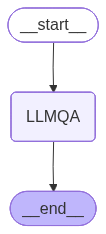

In [9]:
from IPython.display import Image
Image(work_flow.get_graph().draw_mermaid_png())